In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [63]:
logs=pd.DataFrame(pd.read_csv("../data/logs.csv"))
metrics=pd.DataFrame(pd.read_csv("../data/Metrics.csv"))
templates=pd.DataFrame(pd.read_csv("../data/templates.csv"))


In [4]:
logs.head()

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at
0,1,2026-07-29T20:53:34.994000,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46
1,2,2026-07-29T20:53:37.004000,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46
2,3,2026-07-29T20:53:39.005000,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46
3,4,2026-07-29T20:53:41.006000,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46
4,5,2026-07-29T20:53:43.007000,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46


In [5]:
logs.describe()

,id,cluster_id
count,15872.000000,15872.000000
mean,7937.499685,6.160471
std,4581.996617,3.373821
min,1.000000,1.000000
25%,3969.750000,3.000000
50%,7937.500000,6.000000
75%,11905.250000,9.000000
max,15873.000000,12.000000


In [6]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15872 entries, 0 to 15871
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           15872 non-null  int64 
 1   timestamp    15872 non-null  object
 2   level        15872 non-null  object
 3   message      15872 non-null  object
 4   uuid         15872 non-null  object
 5   logger_name  15872 non-null  object
 6   raw_log      15872 non-null  object
 7   cluster_id   15872 non-null  int64 
 8   template     15872 non-null  object
 9   created_at   15872 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.2+ MB


In [7]:
logs.describe(include='all')

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at
count,15872.000000,15872,15872,15872,15872,15872,15872,15872.000000,15872,15872
unique,NaN,15872,3,6970,15872,1,15872,NaN,50,15211
top,NaN,2026-07-30T15:31:22.673000,WARNING,Worker 1 restarted,1719e255-2139-43f0-b416-5e124aca0f13,60 root,"[2026-07-30 15:31:22,673] 60 root - INFO - Con...",NaN,Request <*> <*> took <*> ms,2026-07-29 17:10:57
freq,NaN,1,5383,285,1,15872,1,NaN,2164,63
mean,7937.499685,NaN,NaN,NaN,NaN,NaN,NaN,6.160471,NaN,NaN
std,4581.996617,NaN,NaN,NaN,NaN,NaN,NaN,3.373821,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,3969.750000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
50%,7937.500000,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN
75%,11905.250000,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN


In [8]:
logs.shape

(15872, 10)

In [9]:
logs.isnull().sum()

id             0
timestamp      0
level          0
message        0
uuid           0
logger_name    0
raw_log        0
cluster_id     0
template       0
created_at     0
dtype: int64

In [10]:
logs.duplicated().sum()

np.int64(0)

In [11]:
logs.nunique()

id             15872
timestamp      15872
level              3
message         6970
uuid           15872
logger_name        1
raw_log        15872
cluster_id        12
template          50
created_at     15211
dtype: int64

In [12]:
logs["timestamp"] = pd.to_datetime(
    logs["timestamp"],
    format="mixed"
)

In [13]:
logs.head()

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46


In [14]:
logs["hour"] = logs["timestamp"].dt.hour
logs["min"]=logs["timestamp"].dt.minute
logs["sec"]=logs["timestamp"].dt.second
logs["date"] = logs["timestamp"].dt.date
logs["weekday"] = logs["timestamp"].dt.day_name()

In [15]:
logs.head(20)

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,hour,min,sec,date,weekday
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,20,53,34,2026-07-29,Wednesday
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,20,53,37,2026-07-29,Wednesday
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,20,53,39,2026-07-29,Wednesday
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,20,53,41,2026-07-29,Wednesday
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,20,53,43,2026-07-29,Wednesday
5,7,2026-07-29 20:53:47.009,WARNING,Memory usage reached 84%,8be97af0-2588-467d-b775-4257b5d85e45,60 root,"[2026-07-29 20:53:47,009] 60 root - WARNING - ...",6,Memory usage reached 84%,2026-07-29 15:23:48,20,53,47,2026-07-29,Wednesday
6,8,2026-07-29 20:53:49.010,WARNING,Database timeout after 34 seconds,8c038ee6-34ed-41e2-9e09-379ac61d5c55,60 root,"[2026-07-29 20:53:49,010] 60 root - WARNING - ...",7,Database timeout after 34 seconds,2026-07-29 15:23:50,20,53,49,2026-07-29,Wednesday
7,9,2026-07-29 20:53:51.011,ERROR,Worker 2 restarted,903aedf2-3d1c-4a21-b398-6311bc73b6b1,60 root,"[2026-07-29 20:53:51,011] 60 root - ERROR - Wo...",2,Worker 2 restarted,2026-07-29 15:23:52,20,53,51,2026-07-29,Wednesday
8,10,2026-07-29 20:53:53.012,INFO,Connection from 192.168.1.152 accepted,b253af61-c6c3-4c93-9b8f-0348aed00199,60 root,"[2026-07-29 20:53:53,012] 60 root - INFO - Con...",5,Connection from <*> accepted,2026-07-29 15:23:54,20,53,53,2026-07-29,Wednesday
9,11,2026-07-29 20:53:55.013,ERROR,User 1542 logged in,09f3c7e6-7a16-44ab-8c0f-bd4036adb88b,60 root,"[2026-07-29 20:53:55,013] 60 root - ERROR - Us...",1,User <*> logged in,2026-07-29 15:23:56,20,53,55,2026-07-29,Wednesday


In [17]:
logs.drop(columns=["weekday"])

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,hour,min,sec,date
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,20,53,34,2026-07-29
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,20,53,37,2026-07-29
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,20,53,39,2026-07-29
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,20,53,41,2026-07-29
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,20,53,43,2026-07-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15867,15869,2026-07-30 15:31:46.683,INFO,Memory usage reached 72%,4c7440a0-df08-4e27-979b-4f69734baabd,60 root,"[2026-07-30 15:31:46,683] 60 root - INFO - Mem...",6,Memory usage reached <*>,2026-07-30 10:01:48,15,31,46,2026-07-30
15868,15870,2026-07-30 15:31:48.684,WARNING,Payment for Order 12670 failed,91d295d3-d438-45b3-80c9-949c29a2ba2a,60 root,"[2026-07-30 15:31:48,684] 60 root - WARNING - ...",4,Payment for Order <*> <*>,2026-07-30 10:01:50,15,31,48,2026-07-30
15869,15871,2026-07-30 15:31:50.685,INFO,Disk usage reached 82%,32733cd8-dd9e-4b88-9a86-d654053a0a3e,60 root,"[2026-07-30 15:31:50,685] 60 root - INFO - Dis...",8,Disk usage reached <*>,2026-07-30 10:01:52,15,31,50,2026-07-30
15870,15872,2026-07-30 15:31:52.685,INFO,Request POST /api/payment took 1334 ms,24b72065-95e2-4625-99a9-fc30f8e8d068,60 root,"[2026-07-30 15:31:52,685] 60 root - INFO - Req...",3,Request <*> <*> took <*> ms,2026-07-30 10:01:54,15,31,52,2026-07-30


In [18]:
logs["level"].value_counts()

level
WARNING    5383
ERROR      5284
INFO       5205
Name: count, dtype: int64

In [19]:
logs["cluster_id"].value_counts()

cluster_id
3     1762
7     1643
1     1597
4     1595
8     1428
5     1380
10    1257
11    1085
6     1053
12    1050
9     1032
2      990
Name: count, dtype: int64

In [20]:
logs["template"].value_counts().head()

template
Request <*> <*> took <*> ms           2164
User <*> logged <*>                   2154
Payment for Order <*> <*>             2116
Database timeout after <*> seconds    1143
Connection from <*> accepted          1072
Name: count, dtype: int64

In [21]:
logs["logger_name"].value_counts()

logger_name
60 root    15872
Name: count, dtype: int64

In [22]:
logs["message_length"] = logs["message"].str.len()

In [23]:
logs.head()

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,hour,min,sec,date,weekday,message_length
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,20,53,34,2026-07-29,Wednesday,19
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,20,53,37,2026-07-29,Wednesday,18
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,20,53,39,2026-07-29,Wednesday,30
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,20,53,41,2026-07-29,Wednesday,38
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,20,53,43,2026-07-29,Wednesday,38


<Axes: xlabel='message_length', ylabel='Count'>

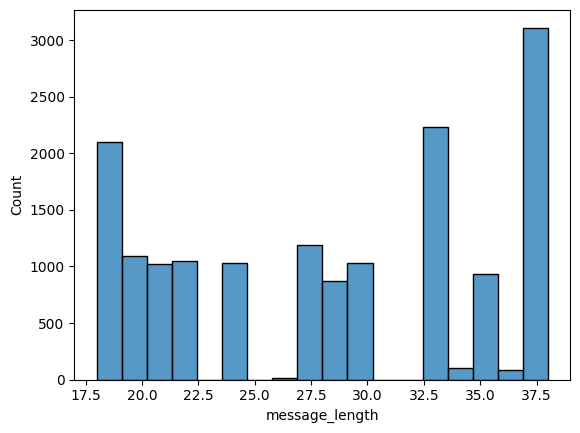

In [24]:
sns.histplot(logs['message_length'])

In [25]:
logs["contains_number"] = logs["message"].str.contains(r"\d")

In [26]:
logs.head()

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,hour,min,sec,date,weekday,message_length,contains_number
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,20,53,34,2026-07-29,Wednesday,19,True
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,20,53,37,2026-07-29,Wednesday,18,True
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,20,53,39,2026-07-29,Wednesday,30,True
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,20,53,41,2026-07-29,Wednesday,38,True
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,20,53,43,2026-07-29,Wednesday,38,True


<Axes: ylabel='count'>

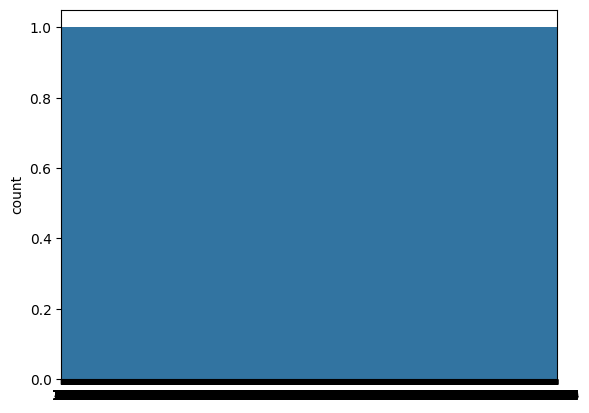

In [27]:
sns.countplot(logs['contains_number'])

In [28]:
logs['cluster_freq']= logs.groupby("cluster_id").size()

In [29]:
logs.head(100)

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,hour,min,sec,date,weekday,message_length,contains_number,cluster_freq
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,20,53,34,2026-07-29,Wednesday,19,True,NaN
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,20,53,37,2026-07-29,Wednesday,18,True,1597.0
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,20,53,39,2026-07-29,Wednesday,30,True,990.0
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,20,53,41,2026-07-29,Wednesday,38,True,1762.0
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,20,53,43,2026-07-29,Wednesday,38,True,1595.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,97,2026-07-29 20:56:47.119,WARNING,User 9227 logged in,3e10a3d0-948e-49bc-9e44-e454b308d7b0,60 root,"[2026-07-29 20:56:47,119] 60 root - WARNING - ...",1,User <*> logged <*>,2026-07-29 15:26:48,20,56,47,2026-07-29,Wednesday,19,True,NaN
96,98,2026-07-29 20:56:49.120,ERROR,Database timeout after 22 seconds,2687c6ed-2de1-4d40-ae3b-653e71d2b7c9,60 root,"[2026-07-29 20:56:49,120] 60 root - ERROR - Da...",7,Database timeout after <*> seconds,2026-07-29 15:26:50,20,56,49,2026-07-29,Wednesday,33,True,NaN
97,99,2026-07-29 20:56:51.121,INFO,Database timeout after 30 seconds,53decc37-ee89-4778-ab9d-ecae628e0b17,60 root,"[2026-07-29 20:56:51,121] 60 root - INFO - Dat...",7,Database timeout after <*> seconds,2026-07-29 15:26:52,20,56,51,2026-07-29,Wednesday,33,True,NaN
98,100,2026-07-29 20:56:53.122,ERROR,Connection from 192.168.1.87 accepted,18c584c0-05cf-4a60-af2e-8cea6f5dd01c,60 root,"[2026-07-29 20:56:53,122] 60 root - ERROR - Co...",5,Connection from <*> accepted,2026-07-29 15:26:54,20,56,53,2026-07-29,Wednesday,37,True,NaN


In [30]:
logs["timestamp"].dtype

dtype('<M8[ns]')

In [31]:
logs["timestamp"].isna().sum()

np.int64(0)

In [32]:
logs["timestamp"].head()

0   2026-07-29 20:53:34.994
1   2026-07-29 20:53:37.004
2   2026-07-29 20:53:39.005
3   2026-07-29 20:53:41.006
4   2026-07-29 20:53:43.007
Name: timestamp, dtype: datetime64[ns]

In [33]:
logs_per_minute = logs.resample("1min", on="timestamp").size()

In [34]:
logs['logs_per_minute']=logs_per_minute

In [35]:
logs

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,hour,min,sec,date,weekday,message_length,contains_number,cluster_freq,logs_per_minute
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,20,53,34,2026-07-29,Wednesday,19,True,NaN,NaN
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,20,53,37,2026-07-29,Wednesday,18,True,1597.0,NaN
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,20,53,39,2026-07-29,Wednesday,30,True,990.0,NaN
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,20,53,41,2026-07-29,Wednesday,38,True,1762.0,NaN
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,20,53,43,2026-07-29,Wednesday,38,True,1595.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15867,15869,2026-07-30 15:31:46.683,INFO,Memory usage reached 72%,4c7440a0-df08-4e27-979b-4f69734baabd,60 root,"[2026-07-30 15:31:46,683] 60 root - INFO - Mem...",6,Memory usage reached <*>,2026-07-30 10:01:48,15,31,46,2026-07-30,Thursday,24,True,NaN,NaN
15868,15870,2026-07-30 15:31:48.684,WARNING,Payment for Order 12670 failed,91d295d3-d438-45b3-80c9-949c29a2ba2a,60 root,"[2026-07-30 15:31:48,684] 60 root - WARNING - ...",4,Payment for Order <*> <*>,2026-07-30 10:01:50,15,31,48,2026-07-30,Thursday,30,True,NaN,NaN
15869,15871,2026-07-30 15:31:50.685,INFO,Disk usage reached 82%,32733cd8-dd9e-4b88-9a86-d654053a0a3e,60 root,"[2026-07-30 15:31:50,685] 60 root - INFO - Dis...",8,Disk usage reached <*>,2026-07-30 10:01:52,15,31,50,2026-07-30,Thursday,22,True,NaN,NaN
15870,15872,2026-07-30 15:31:52.685,INFO,Request POST /api/payment took 1334 ms,24b72065-95e2-4625-99a9-fc30f8e8d068,60 root,"[2026-07-30 15:31:52,685] 60 root - INFO - Req...",3,Request <*> <*> took <*> ms,2026-07-30 10:01:54,15,31,52,2026-07-30,Thursday,38,True,NaN,NaN


In [36]:
print(logs["timestamp"].dtype)

print(logs["timestamp"].head())

print(logs_per_minute.head(10))

datetime64[ns]
0   2026-07-29 20:53:34.994
1   2026-07-29 20:53:37.004
2   2026-07-29 20:53:39.005
3   2026-07-29 20:53:41.006
4   2026-07-29 20:53:43.007
Name: timestamp, dtype: datetime64[ns]
timestamp
2026-07-29 20:53:00    12
2026-07-29 20:54:00    30
2026-07-29 20:55:00    30
2026-07-29 20:56:00    30
2026-07-29 20:57:00    30
2026-07-29 20:58:00    30
2026-07-29 20:59:00    30
2026-07-29 21:00:00    30
2026-07-29 21:01:00    30
2026-07-29 21:02:00    30
Freq: min, dtype: int64


In [37]:
logs["minute"] = logs["timestamp"].dt.floor("min")

logs_per_minute = (
    logs.groupby("minute")
        .size()
        .rename("logs_per_minute")
)

logs = logs.merge(
    logs_per_minute,
    left_on="minute",
    right_index=True,
    how="left"
)

In [44]:
logs.head()

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,...,sec,date,weekday,message_length,contains_number,cluster_freq,logs_per_minute_x,minute,logs_per_minute_y,word_count
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,...,34,2026-07-29,Wednesday,19,True,NaN,NaN,2026-07-29 20:53:00,12,4
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,...,37,2026-07-29,Wednesday,18,True,1597.0,NaN,2026-07-29 20:53:00,12,3
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,...,39,2026-07-29,Wednesday,30,True,990.0,NaN,2026-07-29 20:53:00,12,5
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,...,41,2026-07-29,Wednesday,38,True,1762.0,NaN,2026-07-29 20:53:00,12,6
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,...,43,2026-07-29,Wednesday,38,True,1595.0,NaN,2026-07-29 20:53:00,12,4


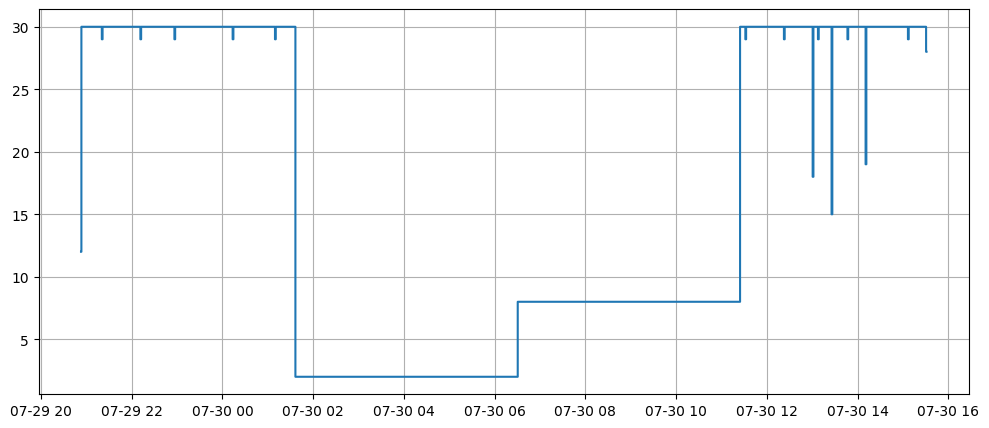

In [39]:
plt.figure(figsize=(12,5))
plt.step(logs_per_minute.index, logs_per_minute.values, where="mid")
plt.grid(True)
plt.show()

<Axes: xlabel='message_length', ylabel='Count'>

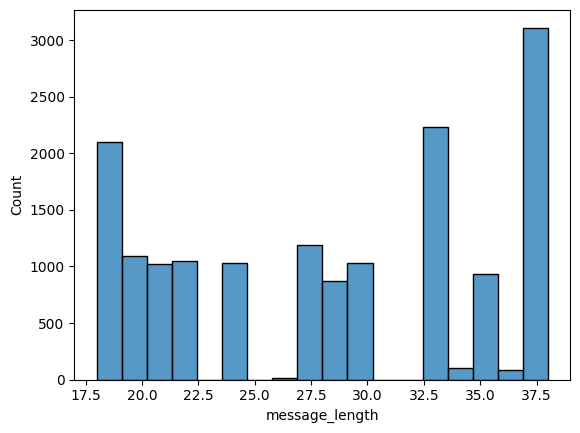

In [40]:
sns.histplot(logs['message_length'])

<Axes: xlabel='word_count', ylabel='Count'>

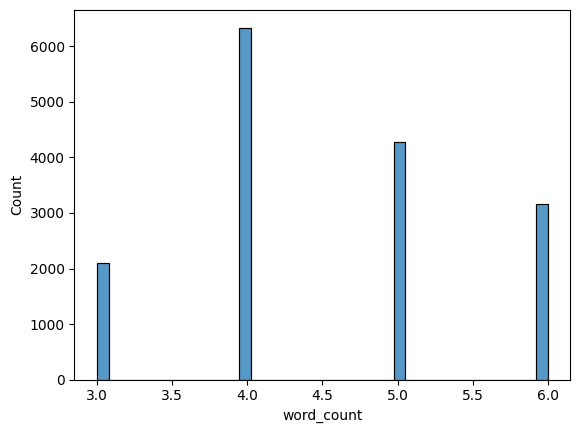

In [41]:
logs["word_count"] = logs["message"].str.split().str.len()
sns.histplot(logs['word_count'])

In [46]:
logs.columns

Index(['id', 'timestamp', 'level', 'message', 'uuid', 'logger_name', 'raw_log',
       'cluster_id', 'template', 'created_at', 'hour', 'min', 'sec', 'date',
       'weekday', 'message_length', 'contains_number', 'cluster_freq',
       'logs_per_minute_x', 'minute', 'logs_per_minute_y', 'word_count'],
      dtype='object')

In [49]:
logs = logs.drop(columns=["logs_per_minute_x"])

logs = logs.rename(
    columns={"logs_per_minute_y": "logs_per_minute"}
)

In [53]:
logs["contains_number"] = logs["message"].str.contains(r"\d").astype(int)

logs["contains_ip"] = logs["message"].str.contains(
    r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
    regex=True
).astype(int)

logs["template_length"] = logs["template"].str.len()

In [54]:
logs.head()

,id,timestamp,level,message,uuid,logger_name,raw_log,cluster_id,template,created_at,...,date,weekday,message_length,contains_number,cluster_freq,minute,logs_per_minute,word_count,contains_ip,template_length
0,1,2026-07-29 20:53:34.994,WARNING,User 4003 logged in,512471f5-f355-496e-88ad-9db965dc5093,60 root,"[2026-07-29 20:53:34,994] 60 root - WARNING - ...",1,User 4003 logged in,2026-07-29 15:23:46,...,2026-07-29,Wednesday,19,1,NaN,2026-07-29 20:53:00,12,4,0,19
1,2,2026-07-29 20:53:37.004,WARNING,Worker 2 restarted,504b5c6e-d177-4b8a-afca-a4886218c3aa,60 root,"[2026-07-29 20:53:37,004] 60 root - WARNING - ...",2,Worker 2 restarted,2026-07-29 15:23:46,...,2026-07-29,Wednesday,18,1,1597.0,2026-07-29 20:53:00,12,3,0,18
2,3,2026-07-29 20:53:39.005,INFO,Payment for Order 54535 failed,7e9f8990-8bdf-4f16-b2a1-eaebd4385ad4,60 root,"[2026-07-29 20:53:39,005] 60 root - INFO - Pay...",3,Payment for Order 54535 failed,2026-07-29 15:23:46,...,2026-07-29,Wednesday,30,1,990.0,2026-07-29 20:53:00,12,5,0,30
3,4,2026-07-29 20:53:41.006,WARNING,Service auth restarted after 2 crashes,2aa3424f-a6de-44f9-acb1-bc5710abc4a2,60 root,"[2026-07-29 20:53:41,006] 60 root - WARNING - ...",4,Service auth restarted after 2 crashes,2026-07-29 15:23:46,...,2026-07-29,Wednesday,38,1,1762.0,2026-07-29 20:53:00,12,6,0,38
4,5,2026-07-29 20:53:43.007,ERROR,Connection from 192.168.1.232 accepted,23ae7c8f-4527-468a-87a8-99ad84595a97,60 root,"[2026-07-29 20:53:43,007] 60 root - ERROR - Co...",5,Connection from 192.168.1.232 accepted,2026-07-29 15:23:46,...,2026-07-29,Wednesday,38,1,1595.0,2026-07-29 20:53:00,12,4,1,38


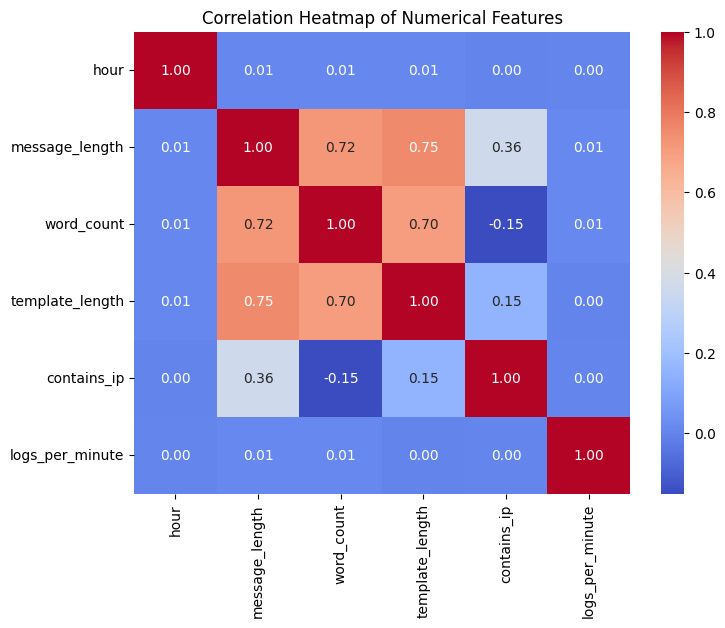

In [57]:
numeric_cols = [
    "hour",
  
    "message_length",
    "word_count",
    "template_length",
    
    "contains_ip",
    "logs_per_minute"
]
corr = logs[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [60]:
logs.to_csv('../data/cleaned_logs.csv',index=False)

In [61]:
metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15872 entries, 0 to 15871
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           15872 non-null  int64 
 1   timestamp    15872 non-null  object
 2   level        15872 non-null  object
 3   message      15872 non-null  object
 4   uuid         15872 non-null  object
 5   logger_name  15872 non-null  object
 6   raw_log      15872 non-null  object
 7   cluster_id   15872 non-null  int64 
 8   template     15872 non-null  object
 9   created_at   15872 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.2+ MB


In [64]:
metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count
0,128,2026-07-29T20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297
1,129,2026-07-29T20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297
2,130,2026-07-29T20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297
3,131,2026-07-29T20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297
4,132,2026-07-29T20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298


In [67]:
metrics.describe(include='all')

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count
count,16051.000000,16051,16051.000000,16051.000000,16051.000000,1.605100e+04,1.605100e+04,16051.000000
unique,NaN,16051,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2026-07-30T16:36:12.371632,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,8153.000000,NaN,16.098025,89.813613,85.125836,5.250973e+08,3.598223e+09,310.549125
std,4633.668921,NaN,12.997758,3.594840,0.470415,3.832560e+08,2.590636e+09,4.818565
min,128.000000,NaN,0.000000,77.100000,84.400000,2.643349e+08,1.870189e+09,295.000000
25%,4140.500000,NaN,6.600000,87.100000,84.600000,2.985402e+08,2.153638e+09,307.000000
50%,8153.000000,NaN,12.700000,90.100000,85.200000,3.678729e+08,2.431668e+09,310.000000
75%,12165.500000,NaN,21.850000,92.700000,85.300000,3.777972e+08,2.444995e+09,313.000000


In [69]:
metrics.isnull().sum()

id                0
timestamp         0
cpu_percent       0
memory_percent    0
disk_percent      0
network_sent      0
network_recv      0
process_count     0
dtype: int64

In [70]:
metrics.nunique()

id                16051
timestamp         16051
cpu_percent         704
memory_percent      202
disk_percent         19
network_sent      13808
network_recv      14164
process_count        49
dtype: int64

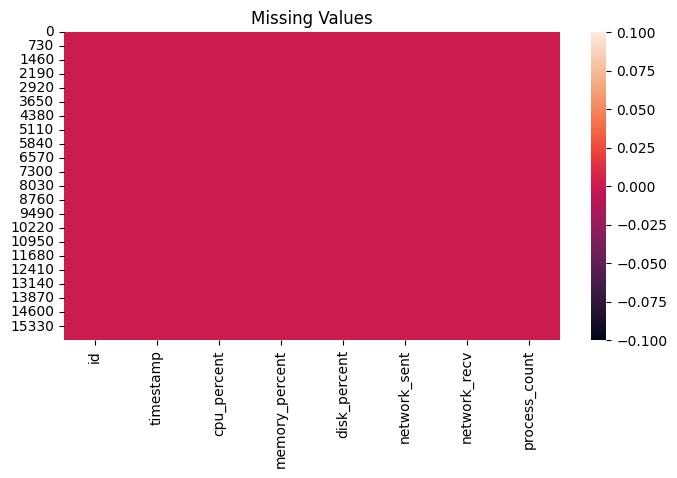

In [72]:
plt.figure(figsize=(8,4))
sns.heatmap(metrics.isnull())
plt.title("Missing Values")
plt.show()

In [73]:
metrics.duplicated().sum()

np.int64(0)

In [74]:
metrics["timestamp"] = pd.to_datetime(metrics["timestamp"])

metrics["hour"] = metrics["timestamp"].dt.hour
metrics["minute"] = metrics["timestamp"].dt.minute
metrics["second"] = metrics["timestamp"].dt.second
metrics["date"] = metrics["timestamp"].dt.date
metrics["weekday"] = metrics["timestamp"].dt.day_name()

In [75]:
metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,second,date,weekday
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,53,2026-07-29,Wednesday
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,56,2026-07-29,Wednesday
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,59,2026-07-29,Wednesday
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,2,2026-07-29,Wednesday
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,5,2026-07-29,Wednesday


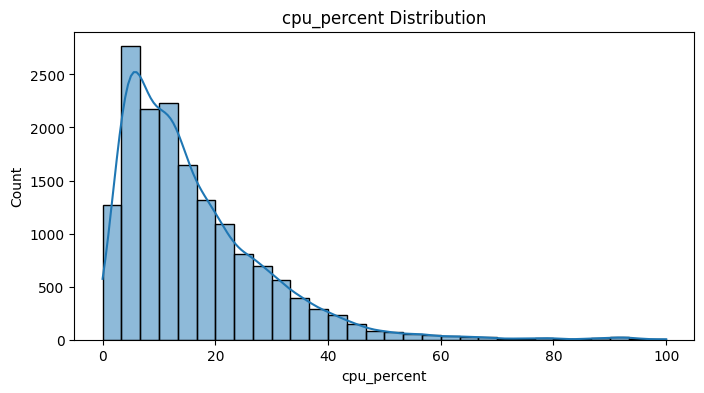

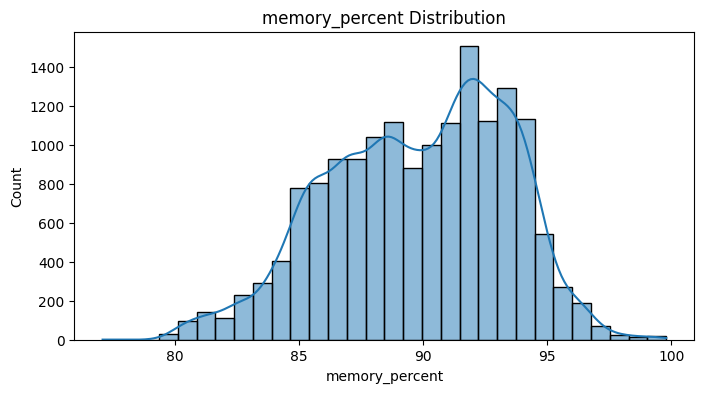

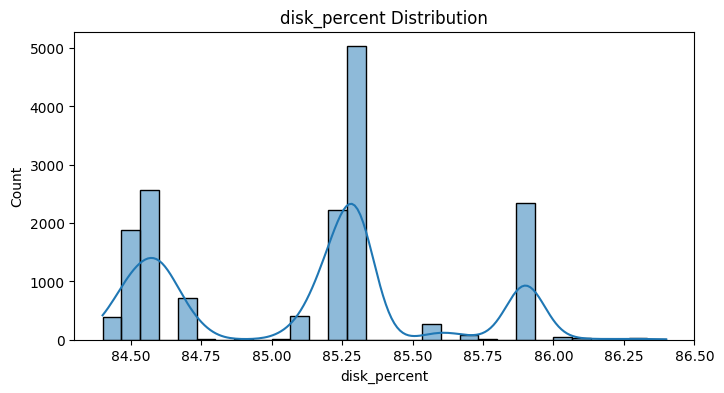

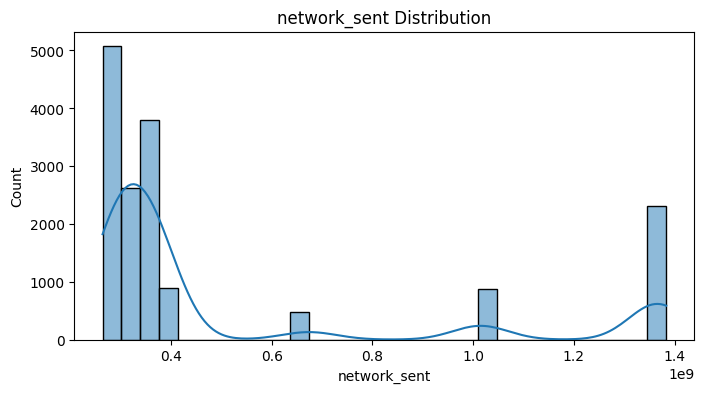

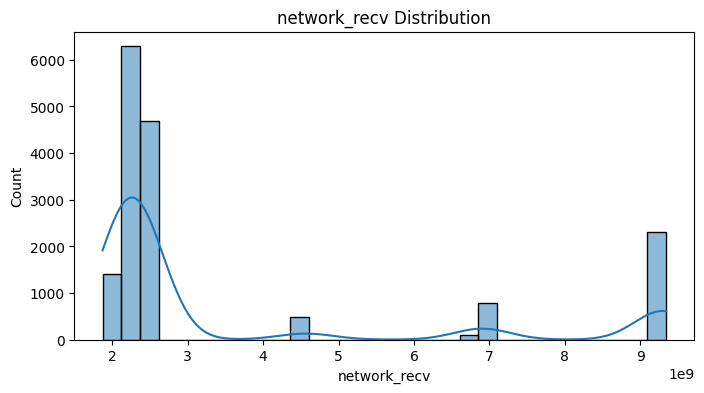

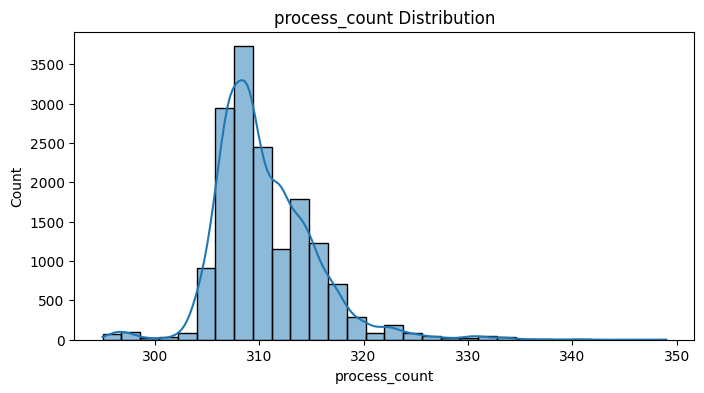

In [76]:
numeric_cols = [
    "cpu_percent",
    "memory_percent",
    "disk_percent",
    "network_sent",
    "network_recv",
    "process_count"
]

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(metrics[col], bins=30, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

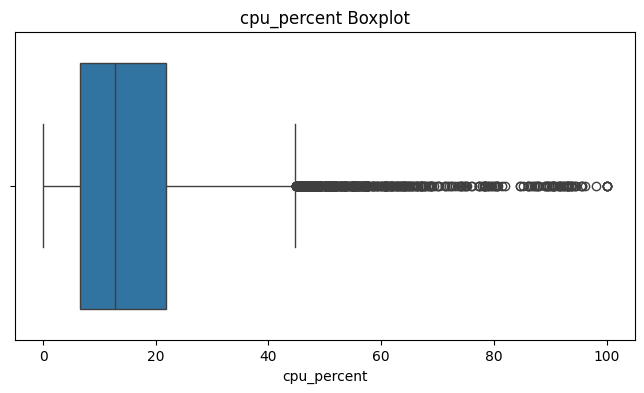

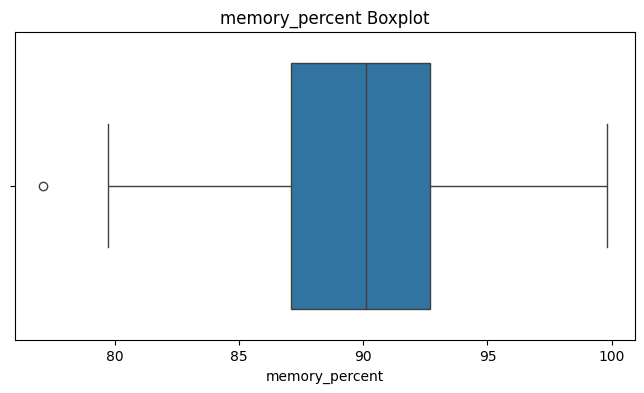

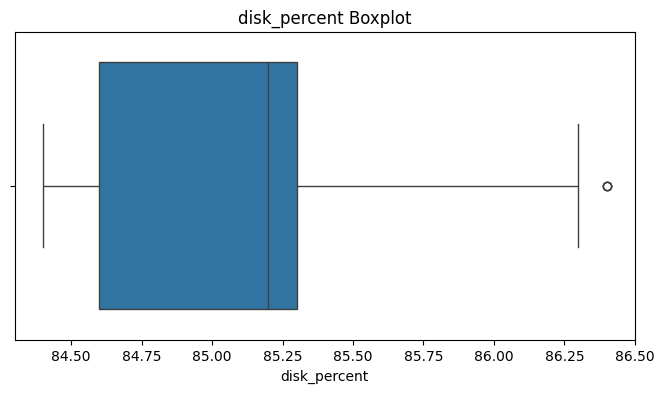

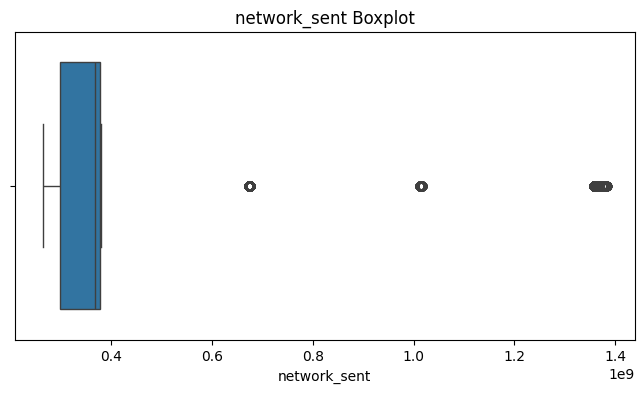

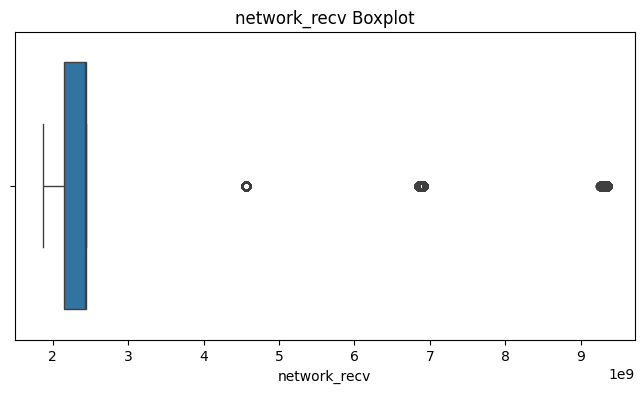

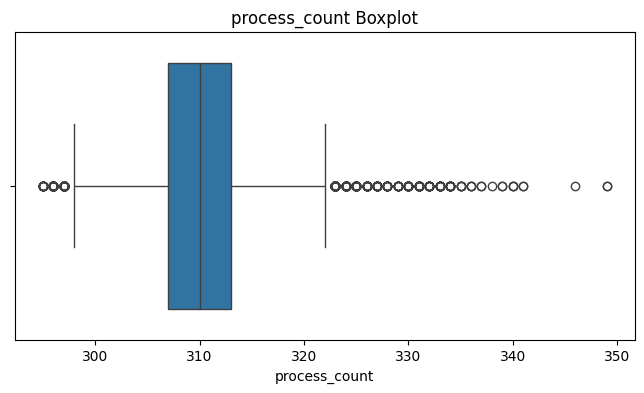

In [78]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=metrics[col])
    plt.title(f"{col} Boxplot")
    plt.show()

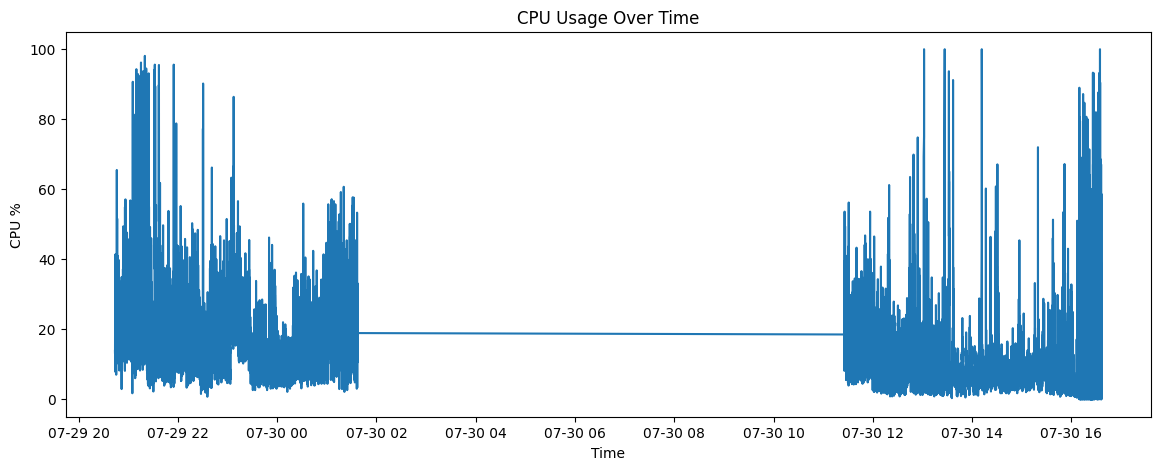

In [79]:
plt.figure(figsize=(14,5))
plt.plot(metrics["timestamp"], metrics["cpu_percent"])
plt.title("CPU Usage Over Time")
plt.xlabel("Time")
plt.ylabel("CPU %")
plt.show()

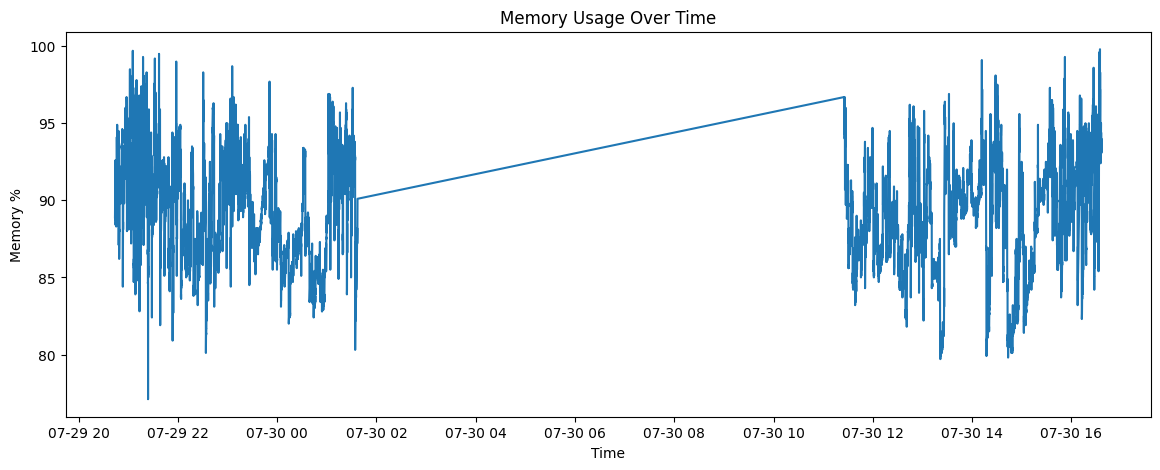

In [81]:
plt.figure(figsize=(14,5))
plt.plot(metrics["timestamp"], metrics["memory_percent"])
plt.title("Memory Usage Over Time")
plt.xlabel("Time")
plt.ylabel("Memory %")
plt.show()

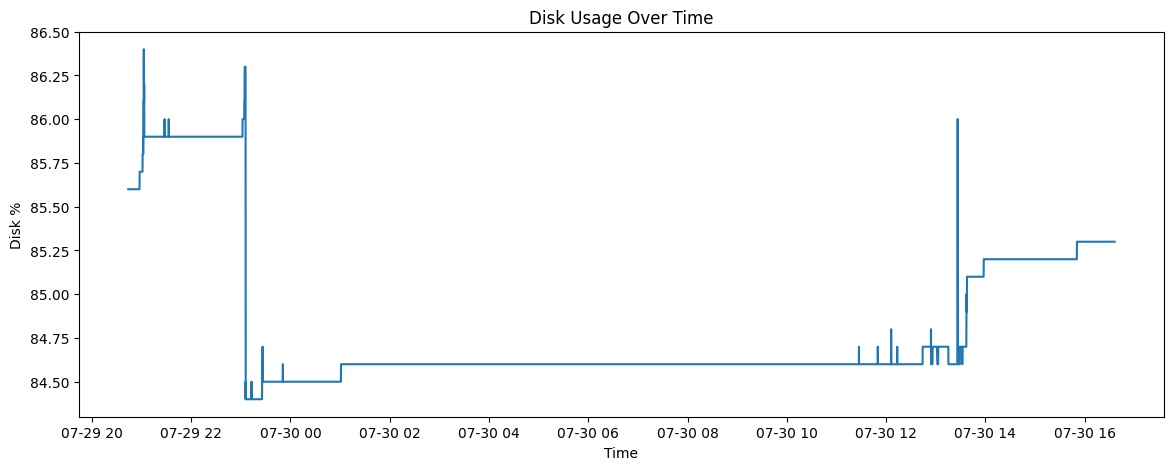

In [82]:
plt.figure(figsize=(14,5))
plt.plot(metrics["timestamp"], metrics["disk_percent"])
plt.title("Disk Usage Over Time")
plt.xlabel("Time")
plt.ylabel("Disk %")
plt.show()

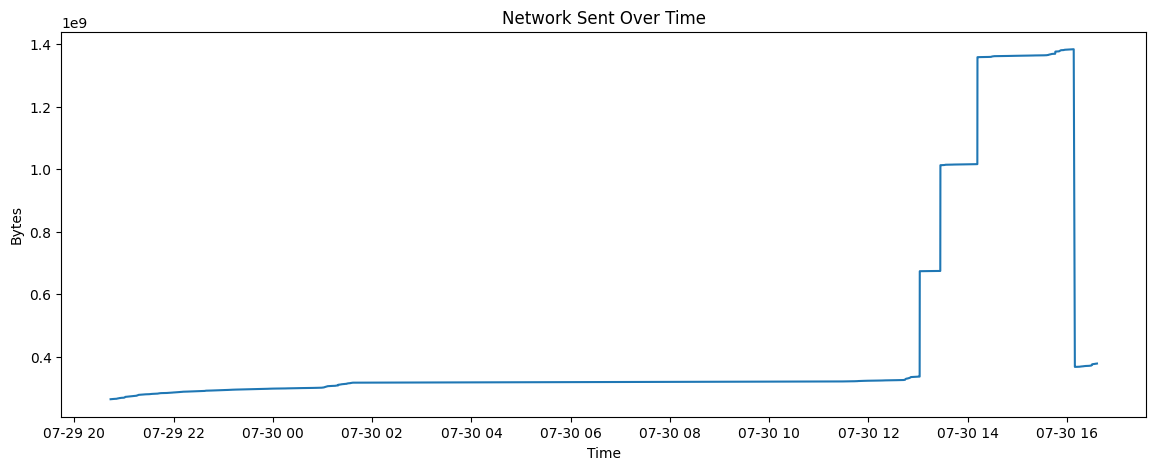

In [83]:
plt.figure(figsize=(14,5))
plt.plot(metrics["timestamp"], metrics["network_sent"])
plt.title("Network Sent Over Time")
plt.xlabel("Time")
plt.ylabel("Bytes")
plt.show()

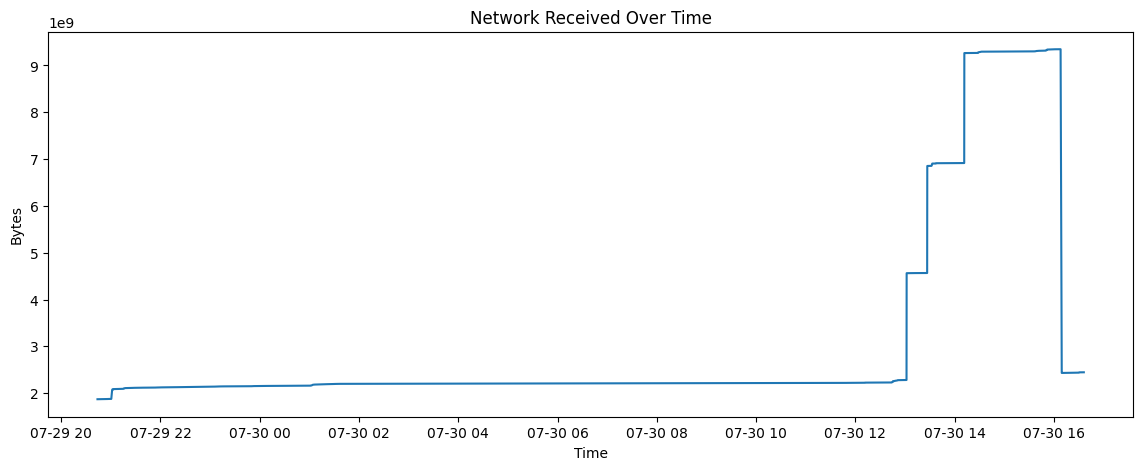

In [84]:
plt.figure(figsize=(14,5))
plt.plot(metrics["timestamp"], metrics["network_recv"])
plt.title("Network Received Over Time")
plt.xlabel("Time")
plt.ylabel("Bytes")
plt.show()

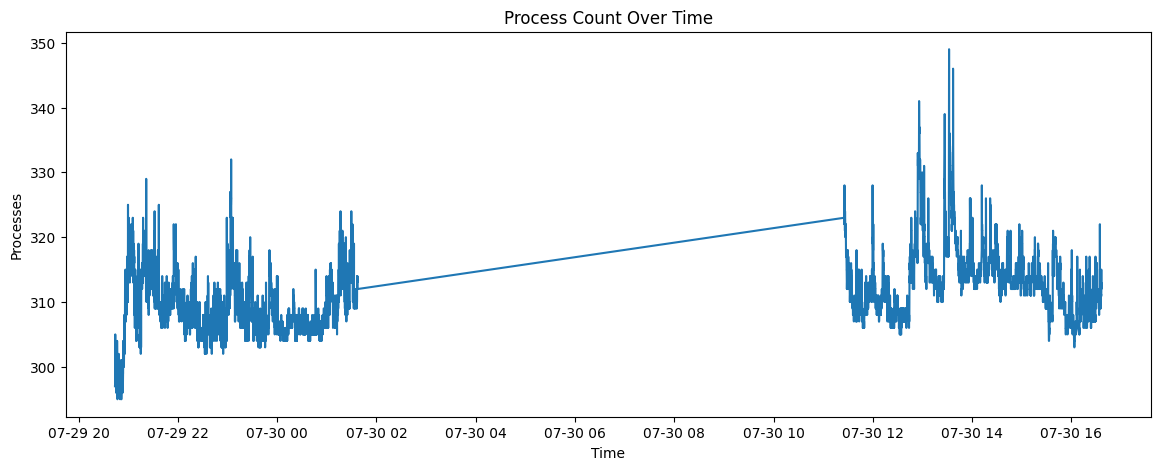

In [85]:
plt.figure(figsize=(14,5))
plt.plot(metrics["timestamp"], metrics["process_count"])
plt.title("Process Count Over Time")
plt.xlabel("Time")
plt.ylabel("Processes")
plt.show()

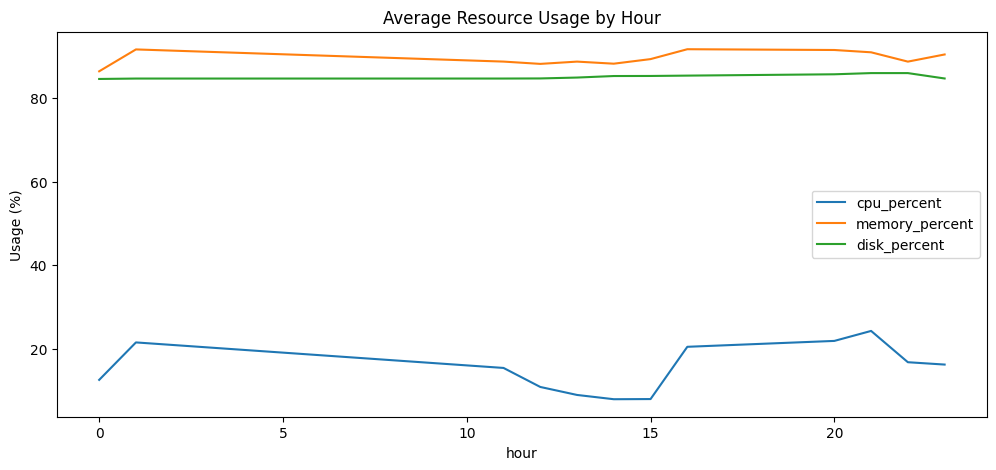

In [86]:
metrics.groupby("hour").mean(numeric_only=True)[
    ["cpu_percent","memory_percent","disk_percent"]
].plot(figsize=(12,5))

plt.title("Average Resource Usage by Hour")
plt.ylabel("Usage (%)")
plt.show()

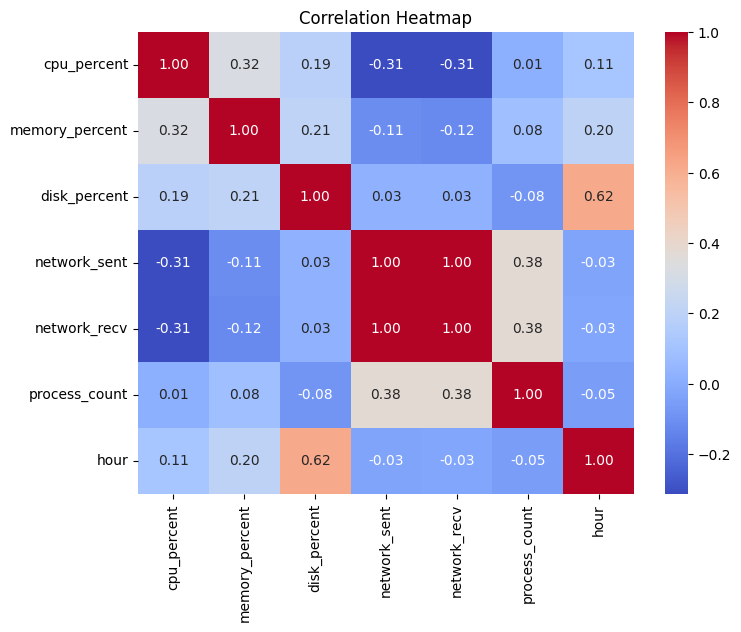

In [87]:
corr = metrics[
    [
        "cpu_percent",
        "memory_percent",
        "disk_percent",
        "network_sent",
        "network_recv",
        "process_count",
        "hour"
    ]
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

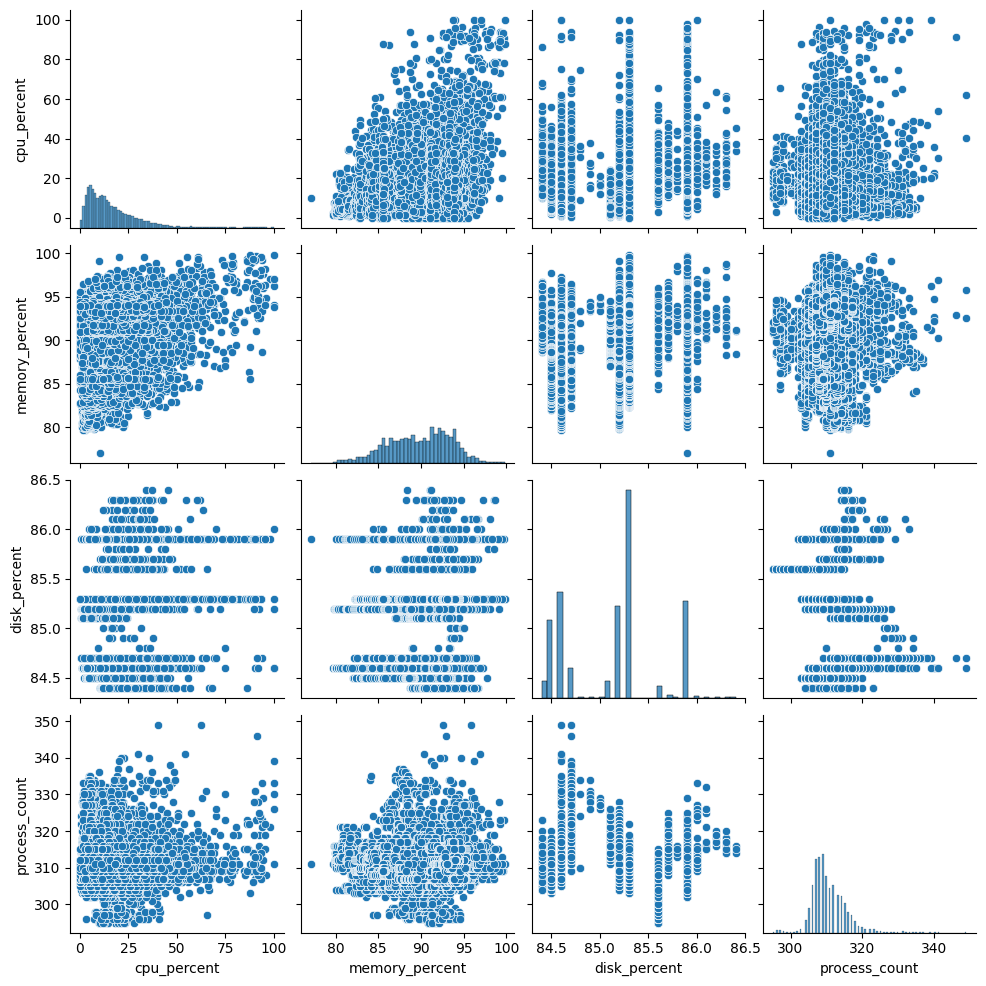

In [88]:
sns.pairplot(
    metrics[
        [
            "cpu_percent",
            "memory_percent",
            "disk_percent",
            "process_count"
        ]
    ]
)
plt.show()

In [89]:
for col in numeric_cols:
    q1 = metrics[col].quantile(0.25)
    q3 = metrics[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    outliers = metrics[
        (metrics[col] < lower) |
        (metrics[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

cpu_percent: 511 outliers
memory_percent: 1 outliers
disk_percent: 3 outliers
network_sent: 3676 outliers
network_recv: 3676 outliers
process_count: 491 outliers


In [90]:
metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,second,date,weekday
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,53,2026-07-29,Wednesday
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,56,2026-07-29,Wednesday
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,59,2026-07-29,Wednesday
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,2,2026-07-29,Wednesday
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,5,2026-07-29,Wednesday


In [100]:
metrics.drop(columns=["weekday"],inplace=True)

In [101]:
metrics.info

<bound method DataFrame.info of           id                  timestamp  cpu_percent  memory_percent  \
0        128 2026-07-29 20:43:53.101717         13.8            88.9   
1        129 2026-07-29 20:43:56.120057         13.0            89.6   
2        130 2026-07-29 20:43:59.193420         21.0            89.2   
3        131 2026-07-29 20:44:02.212411         27.0            89.7   
4        132 2026-07-29 20:44:05.226557         22.9            90.2   
...      ...                        ...          ...             ...   
16046  16174 2026-07-30 16:36:11.077762         25.0            94.0   
16047  16175 2026-07-30 16:36:11.403165          7.5            93.2   
16048  16176 2026-07-30 16:36:11.722569         10.7            93.1   
16049  16177 2026-07-30 16:36:12.048381         18.2            93.1   
16050  16178 2026-07-30 16:36:12.371632         17.9            93.1   

       disk_percent  network_sent  network_recv  process_count  hour  minute  \
0              85.6    

In [102]:
metrics.describe()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,second
count,16051.000000,16051,16051.000000,16051.000000,16051.000000,1.605100e+04,1.605100e+04,16051.000000,16051.000000,16051.000000,16051.000000
mean,8153.000000,2026-07-30 09:16:01.248982528,16.098025,89.813613,85.125836,5.250973e+08,3.598223e+09,310.549125,14.598094,27.635661,29.516728
min,128.000000,2026-07-29 20:43:53.101717,0.000000,77.100000,84.400000,2.643349e+08,1.870189e+09,295.000000,0.000000,0.000000,0.000000
25%,4140.500000,2026-07-30 00:06:45.091401472,6.600000,87.100000,84.600000,2.985402e+08,2.153638e+09,307.000000,13.000000,15.000000,14.000000
50%,8153.000000,2026-07-30 13:18:58.496982016,12.700000,90.100000,85.200000,3.678729e+08,2.431668e+09,310.000000,16.000000,26.000000,30.000000
75%,12165.500000,2026-07-30 16:13:17.554474496,21.850000,92.700000,85.300000,3.777972e+08,2.444995e+09,313.000000,16.000000,39.000000,45.000000
max,16178.000000,2026-07-30 16:36:12.371632,100.000000,99.800000,86.400000,1.383403e+09,9.345427e+09,349.000000,23.000000,59.000000,59.000000
std,4633.668921,NaN,12.997758,3.594840,0.470415,3.832560e+08,2.590636e+09,4.818565,6.238361,15.649214,17.345620


In [103]:
metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16051 entries, 0 to 16050
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              16051 non-null  int64         
 1   timestamp       16051 non-null  datetime64[ns]
 2   cpu_percent     16051 non-null  float64       
 3   memory_percent  16051 non-null  float64       
 4   disk_percent    16051 non-null  float64       
 5   network_sent    16051 non-null  int64         
 6   network_recv    16051 non-null  int64         
 7   process_count   16051 non-null  int64         
 8   hour            16051 non-null  int32         
 9   minute          16051 non-null  int32         
 10  second          16051 non-null  int32         
 11  date            16051 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(3), int64(4), object(1)
memory usage: 1.3+ MB


In [104]:
metrics["hour"] = metrics["timestamp"].dt.hour
metrics["minute"] = metrics["timestamp"].dt.minute
metrics["second"] = metrics["timestamp"].dt.second
metrics["weekday"] = metrics["timestamp"].dt.day_name()

In [105]:
metrics["cpu_diff"] = metrics["cpu_percent"].diff()
metrics["memory_diff"] = metrics["memory_percent"].diff()
metrics["disk_diff"] = metrics["disk_percent"].diff()
metrics["network_sent_diff"] = metrics["network_sent"].diff()
metrics["network_recv_diff"] = metrics["network_recv"].diff()
metrics["process_count_diff"] = metrics["process_count"].diff()

In [106]:
metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,second,date,weekday,cpu_diff,memory_diff,disk_diff,network_sent_diff,network_recv_diff,process_count_diff
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,53,2026-07-29,Wednesday,NaN,NaN,NaN,NaN,NaN,NaN
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,56,2026-07-29,Wednesday,-0.8,0.7,0.0,7954.0,8935.0,0.0
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,59,2026-07-29,Wednesday,8.0,-0.4,0.0,738.0,573.0,0.0
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,2,2026-07-29,Wednesday,6.0,0.5,0.0,27777.0,7097.0,0.0
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,5,2026-07-29,Wednesday,-4.1,0.5,0.0,14059.0,2384.0,1.0


In [107]:
metrics["network_sent_rate"] = metrics["network_sent"].diff()

metrics["network_recv_rate"] = metrics["network_recv"].diff()

metrics["network_total_rate"] = (
    metrics["network_sent_rate"] +
    metrics["network_recv_rate"]
)

In [108]:
metrics["time_diff"] = (
    metrics["timestamp"]
    .diff()
    .dt.total_seconds()
)

In [109]:
metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,...,cpu_diff,memory_diff,disk_diff,network_sent_diff,network_recv_diff,process_count_diff,network_sent_rate,network_recv_rate,network_total_rate,time_diff
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,...,-0.8,0.7,0.0,7954.0,8935.0,0.0,7954.0,8935.0,16889.0,3.018340
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,...,8.0,-0.4,0.0,738.0,573.0,0.0,738.0,573.0,1311.0,3.073363
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,...,6.0,0.5,0.0,27777.0,7097.0,0.0,27777.0,7097.0,34874.0,3.018991
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,...,-4.1,0.5,0.0,14059.0,2384.0,1.0,14059.0,2384.0,16443.0,3.014146


In [110]:
metric_cols = [
    "cpu_percent",
    "memory_percent",
    "disk_percent",
    "network_sent",
    "network_recv",
    "process_count"
]

windows = [5, 10, 30]

for col in metric_cols:
    for window in windows:
        metrics[f"{col}_mean_{window}"] = (
            metrics[col]
            .rolling(window=window, min_periods=1)
            .mean()
        )

for col in metric_cols:
    for window in windows:
        metrics[f"{col}_std_{window}"] = (
            metrics[col]
            .rolling(window=window, min_periods=1)
            .std()
        )

for col in metric_cols:
    for window in windows:
        metrics[f"{col}_max_{window}"] = (
            metrics[col]
            .rolling(window=window, min_periods=1)
            .max()
        )

for col in metric_cols:
    for window in windows:
        metrics[f"{col}_min_{window}"] = (
            metrics[col]
            .rolling(window=window, min_periods=1)
            .min()
        )




In [111]:
metrics.head()

,id,timestamp,cpu_percent,memory_percent,disk_percent,network_sent,network_recv,process_count,hour,minute,...,disk_percent_min_30,network_sent_min_5,network_sent_min_10,network_sent_min_30,network_recv_min_5,network_recv_min_10,network_recv_min_30,process_count_min_5,process_count_min_10,process_count_min_30
0,128,2026-07-29 20:43:53.101717,13.8,88.9,85.6,264334942,1870188592,297,20,43,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
1,129,2026-07-29 20:43:56.120057,13.0,89.6,85.6,264342896,1870197527,297,20,43,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
2,130,2026-07-29 20:43:59.193420,21.0,89.2,85.6,264343634,1870198100,297,20,43,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
3,131,2026-07-29 20:44:02.212411,27.0,89.7,85.6,264371411,1870205197,297,20,44,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0
4,132,2026-07-29 20:44:05.226557,22.9,90.2,85.6,264385470,1870207581,298,20,44,...,85.6,264334942.0,264334942.0,264334942.0,1.870189e+09,1.870189e+09,1.870189e+09,297.0,297.0,297.0


In [114]:
metrics.shape

(16051, 95)

In [115]:
metrics.to_csv('../data/cleaned_metrics.csv',index=False)